# KIVE RL Agent Training Analysis -- RecurrentPPO
This notebook evaluates the performance of the **RecurrentPPO** (LSTM-based PPO) orchestrator agent
trained on the KIVE expert fraud vetting POMDP.

**Architecture Summary:**
- **Observation:** 18D (5 passive signals + 4 active signals + probe flags + beliefs)
- **Actions:** Discrete(7) -- PASS, REJECT, FLAG, PROBE_BES, PROBE_LQA, PROBE_CCS, PROBE_RSL
- **Reward:** Asymmetric -- FN=-2.5 (fraud passed), FP=-1.0, TP/TN=+1.0, Probe=-0.02

**Training Goal:** The agent must learn to:
1. Read passive signals (free) for initial assessment
2. Probe active signals (costly) when uncertain
3. Decide PASS/REJECT/FLAG with minimal false negatives


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#111111",
    "figure.facecolor": "#111111",
    "axes.edgecolor": "#333333",
    "text.color": "white",
})


In [36]:
# Resolve project root
cwd = Path.cwd()
project_root = cwd
while not (project_root / "artifacts" / "training" / "learning_curve.csv").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError(
            f"Could not find 'artifacts/training/learning_curve.csv' above {cwd}. "
            "Upload the 'artifacts' folder."
        )
    project_root = project_root.parent

df = pd.read_csv(project_root / "artifacts" / "training" / "learning_curve.csv")
traces = pd.read_csv(project_root / "artifacts" / "training" / "sample_traces.csv")

print(f"Learning curve: {len(df)} evaluation windows")
print(f"Sample traces: {len(traces)} episodes")
print(f"Columns in learning_curve: {list(df.columns)}")
print(f"Columns in traces: {list(traces.columns)}")
df.tail(5)


Learning curve: 344 evaluation windows
Sample traces: 20 episodes
Columns in learning_curve: ['episode', 'reward_mean', 'reward_std', 'fn_rate', 'fp_rate', 'probes_mean']
Columns in traces: ['true_label', 'n_probes', 'actions', 'final_action']


,episode,reward_mean,reward_std,fn_rate,fp_rate,probes_mean
339,34000,0.9064,0.4437,0.01,0.02,0.75
340,34100,0.8404,0.5530,0.01,0.05,0.88
341,34200,0.8726,0.5572,0.02,0.02,0.78
342,34300,0.9102,0.4414,0.01,0.02,0.74
343,34400,0.8000,0.7684,0.05,0.00,0.89


## 1. Convergence Curve
Dual-axis plot: reward (left) vs false-negative rate (right). The agent must push reward above 0.5 while keeping FN below 10%.

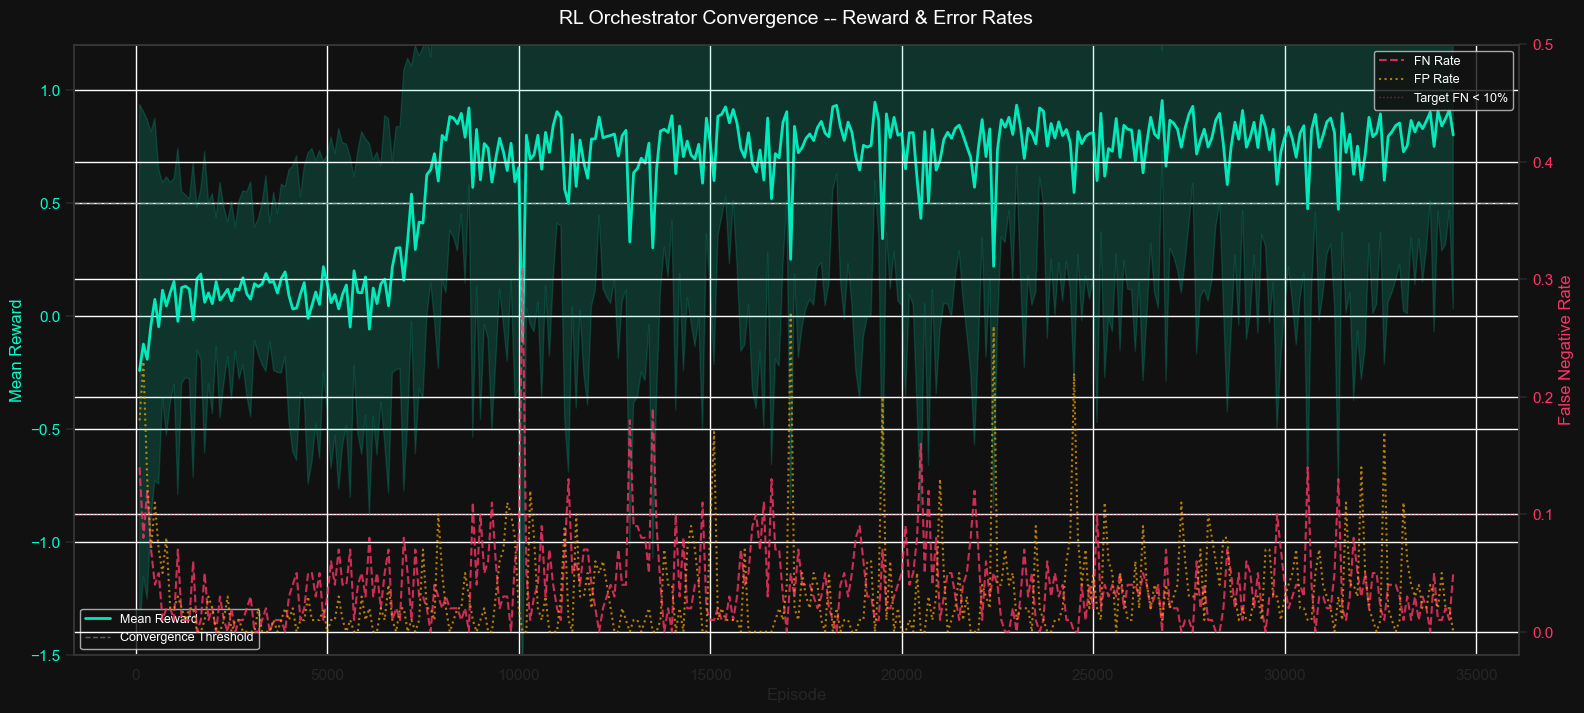

In [37]:
# --- Dual-Axis Convergence Plot ---
fig, ax1 = plt.subplots(figsize=(16, 7))

# Reward curve
color1 = '#00ffcc'
ax1.set_xlabel('Episode', fontsize=12)
ax1.set_ylabel('Mean Reward', color=color1, fontsize=12)
ax1.plot(df['episode'], df['reward_mean'], color=color1, linewidth=2, label='Mean Reward', alpha=0.9)
ax1.fill_between(df['episode'],
                 df['reward_mean'] - df['reward_std'],
                 df['reward_mean'] + df['reward_std'],
                 color=color1, alpha=0.15)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Convergence Threshold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(-1.5, 1.2)

# FN rate on secondary axis
ax2 = ax1.twinx()
color2 = '#ff3366'
ax2.set_ylabel('False Negative Rate', color=color2, fontsize=12)
ax2.plot(df['episode'], df['fn_rate'], color=color2, linewidth=1.5, linestyle='--', label='FN Rate', alpha=0.8)
ax2.plot(df['episode'], df['fp_rate'], color='#ffaa00', linewidth=1.5, linestyle=':', label='FP Rate', alpha=0.7)
ax2.axhline(0.10, color='#ff3366', linestyle=':', linewidth=1, alpha=0.5, label='Target FN < 10%')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(-0.02, 0.5)

fig.tight_layout()
plt.title("RL Orchestrator Convergence -- Reward & Error Rates", color='white', pad=15, fontsize=14)
ax1.legend(loc='lower left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
plt.show()


## 2. Probe Utilization
How many active probes the agent takes per episode over training. A healthy agent learns to probe when passive signals are ambiguous (~0.5-1.5 probes/episode).

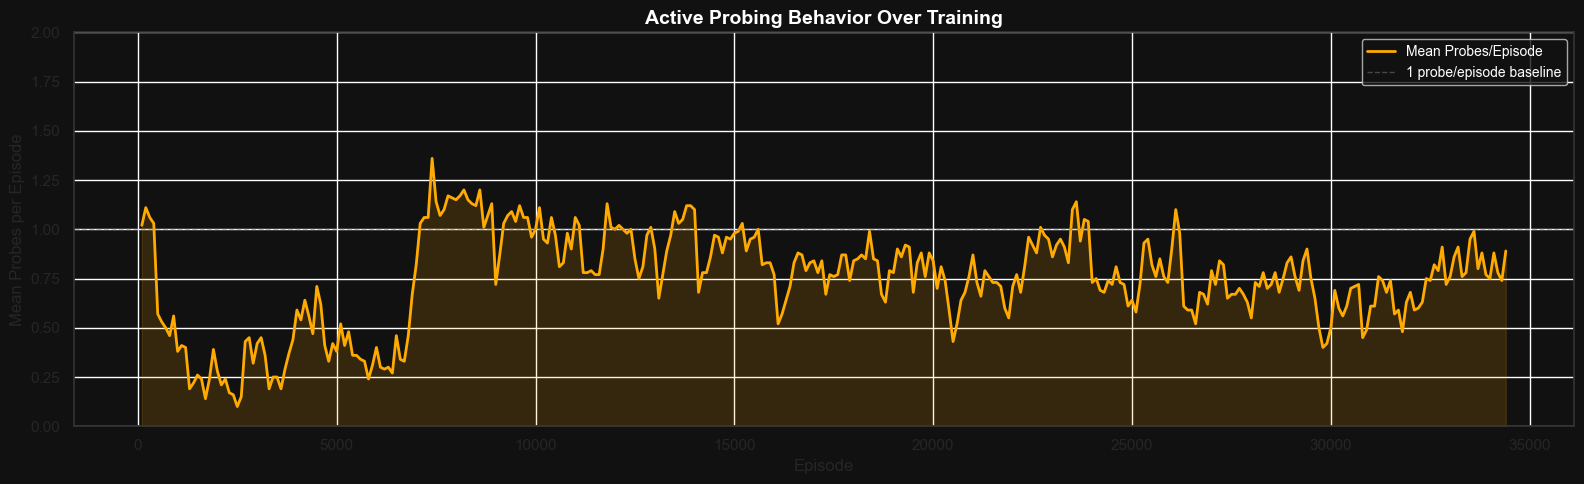

In [38]:
# --- Probe Utilization Over Training ---
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['episode'], df['probes_mean'], color='#ffaa00', linewidth=2, label='Mean Probes/Episode')
ax.fill_between(df['episode'], 0, df['probes_mean'], color='#ffaa00', alpha=0.15)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='1 probe/episode baseline')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean Probes per Episode', fontsize=12)
ax.set_title('Active Probing Behavior Over Training', fontsize=14, fontweight='bold', color='white')
ax.legend(fontsize=10)
ax.set_ylim(0, max(df['probes_mean'].max() * 1.3, 2.0))
plt.tight_layout()
plt.show()


## 3. Final Performance Distribution
Reward and probe distributions from the final evaluation windows.

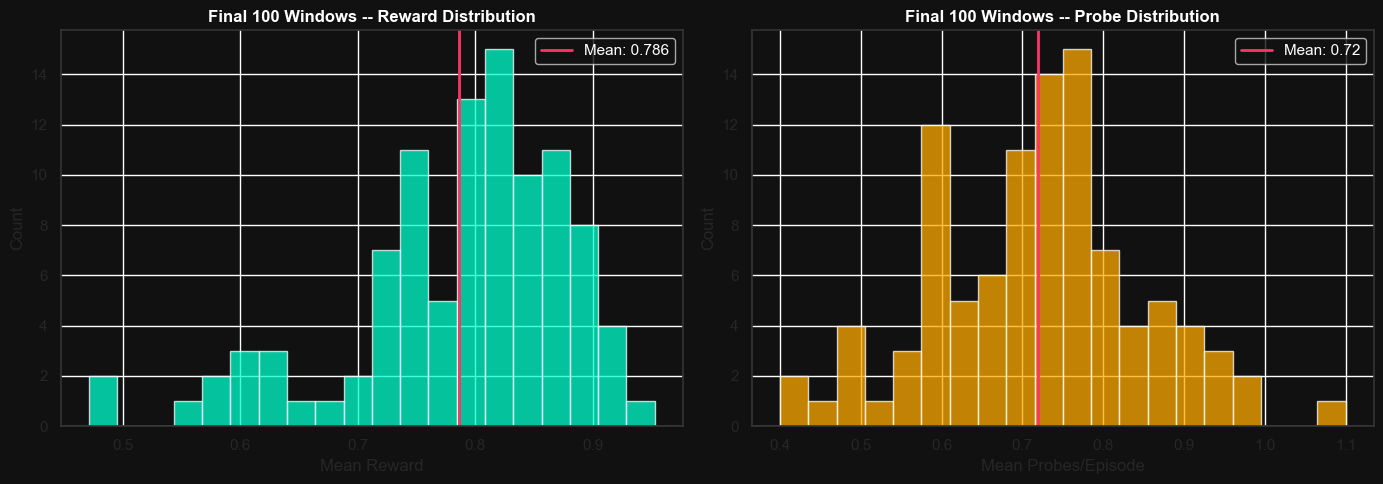

In [39]:
# --- Final Reward Distribution ---
final_n = min(100, len(df))
final_df = df.tail(final_n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reward histogram
ax1.hist(final_df['reward_mean'], bins=20, color='#00ffcc', alpha=0.75, edgecolor='white')
ax1.axvline(final_df['reward_mean'].mean(), color='#ff3366', linewidth=2,
           label=f"Mean: {final_df['reward_mean'].mean():.3f}")
ax1.set_xlabel('Mean Reward')
ax1.set_ylabel('Count')
ax1.set_title(f'Final {final_n} Windows -- Reward Distribution', fontsize=12, fontweight='bold')
ax1.legend()

# Probes histogram
ax2.hist(final_df['probes_mean'], bins=20, color='#ffaa00', alpha=0.75, edgecolor='white')
ax2.axvline(final_df['probes_mean'].mean(), color='#ff3366', linewidth=2,
           label=f"Mean: {final_df['probes_mean'].mean():.2f}")
ax2.set_xlabel('Mean Probes/Episode')
ax2.set_ylabel('Count')
ax2.set_title(f'Final {final_n} Windows -- Probe Distribution', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


## 4. Episode Traces
Raw action sequences from the last 20 episodes showing the agent's probe-then-decide behavior.

In [40]:
# --- Sample Episode Traces ---
print("=== Sample Episode Traces ===")
print(traces.to_string(index=False))


=== Sample Episode Traces ===
true_label  n_probes                                       actions final_action
     FRAUD         3 PROBE_LQA -> PROBE_CCS -> PROBE_CCS -> REJECT       REJECT
     FRAUD         2              PROBE_LQA -> PROBE_RSL -> REJECT       REJECT
      REAL         1                             PROBE_BES -> PASS         PASS
      REAL         1                             PROBE_CCS -> PASS         PASS
     FRAUD         1                           PROBE_CCS -> REJECT       REJECT
     FRAUD         0                                        REJECT       REJECT
     FRAUD         1                           PROBE_CCS -> REJECT       REJECT
      REAL         0                                          PASS         PASS
      REAL         1                             PROBE_RSL -> PASS         PASS
     FRAUD         1                           PROBE_CCS -> REJECT       REJECT
      REAL         2                PROBE_CCS -> PROBE_CCS -> PASS         PASS
      REAL

## 5. Probe & Action Analysis
Breakdown of probing behavior and terminal actions by true label.

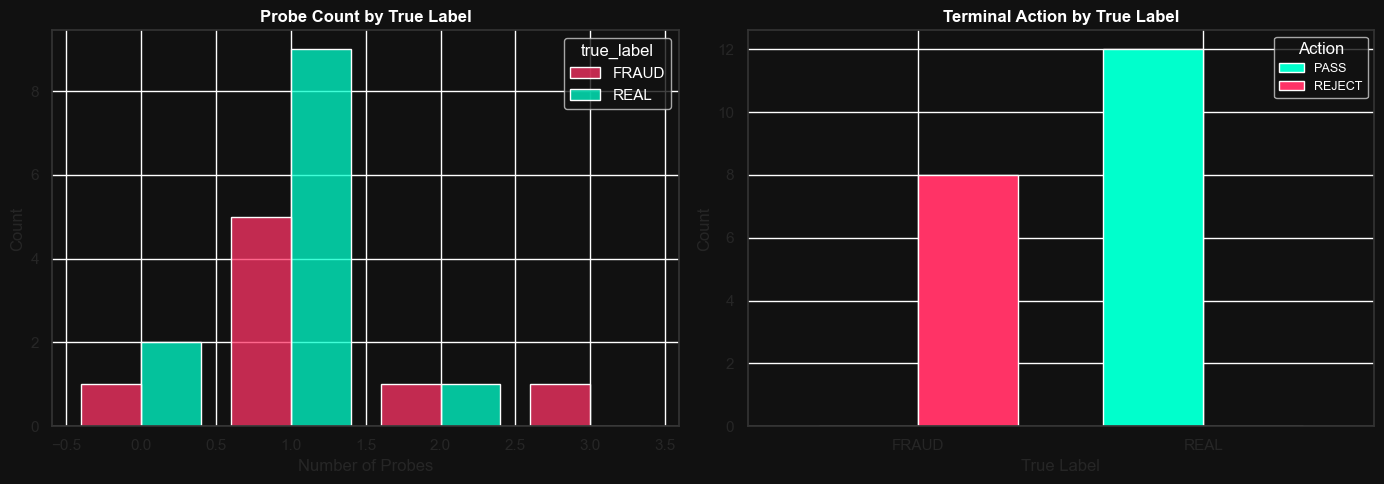

In [41]:
# --- Probe Usage by True Label ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Probe count distribution by label
if 'n_probes' in traces.columns:
    probe_col = 'n_probes'
else:
    probe_col = traces.columns[1]  # fallback to second column

sns.histplot(data=traces, x=probe_col, hue='true_label', multiple='dodge',
            palette={'REAL': '#00ffcc', 'FRAUD': '#ff3366'}, ax=ax1,
            discrete=True, shrink=0.8)
ax1.set_title("Probe Count by True Label", fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel("Number of Probes")
ax1.set_ylabel("Count")

# Terminal action distribution
if 'final_action' in traces.columns:
    action_col = 'final_action'
else:
    action_col = traces.columns[-1]

ct = traces.groupby(['true_label', action_col]).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=ax2, color=['#00ffcc', '#ff3366', '#ffaa00', '#4488ff'][:len(ct.columns)],
       edgecolor='white', width=0.7)
ax2.set_title("Terminal Action by True Label", fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel("True Label")
ax2.set_ylabel("Count")
ax2.legend(title="Action", fontsize=9)
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 6. Convergence Report

In [42]:
# --- Final Convergence Summary ---
import json

report_path = project_root / "artifacts" / "training" / "convergence_report.json"
if report_path.exists():
    report = json.loads(report_path.read_text())
    print("=" * 50)
    print("  KIVE RL Agent Convergence Report")
    print("=" * 50)
    for k, v in report.items():
        print(f"  {k:30s}: {v}")
    print("=" * 50)
    if report.get('converged'):
        print("  STATUS: CONVERGED")
    else:
        print("  STATUS: NOT CONVERGED")
else:
    print("convergence_report.json not found")


  KIVE RL Agent Convergence Report
  run_name                      : kive_ppo_v2
  n_episodes_target             : 10000
  n_episodes_actual             : 34418
  final_mean_reward             : 0.8543
  final_std_reward              : 0.588
  fn_rate                       : 0.021
  fp_rate                       : 0.025
  mean_probes_per_episode       : 0.844
  converged                     : True
  STATUS: CONVERGED
